<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/HuongDan_KNN_Bai2_DuDoanGiaNha_CoCSV_Input.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bước 1: Tạo dữ liệu mô phỏng giao dịch nhà đất

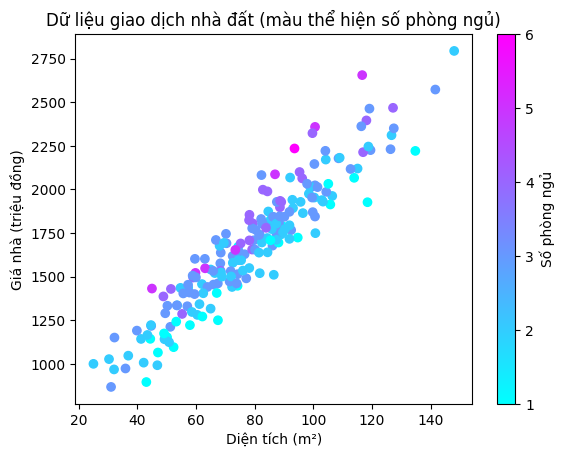

In [70]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

dien_tich = np.random.normal(80, 25, n).clip(25, 200)  # đơn vị: m2
so_phong = np.round(np.random.normal(2.5, 1, n).clip(1, 6))  # số phòng ngủ

# Công thức mô phỏng giá nhà (đơn vị: triệu đồng) + nhiễu ngẫu nhiên
gia_nha = 300 + dien_tich * 15 + so_phong * 80 + np.random.normal(0, 100, n)
gia_nha = gia_nha.clip(300)

X = np.column_stack([dien_tich, so_phong])
y = gia_nha

plt.scatter(dien_tich, gia_nha, c=so_phong, cmap='cool')
plt.xlabel('Diện tích (m²)'); plt.ylabel('Giá nhà (triệu đồng)')
plt.title('Dữ liệu giao dịch nhà đất (màu thể hiện số phòng ngủ)')
plt.colorbar(label='Số phòng ngủ')
plt.show()

Bước 2 (MỚI): Kết nối Google Drive và tạo thư mục lưu dữ liệu

In [71]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Đường dẫn thư mục trên Drive để lưu dữ liệu — có thể đổi tên tùy ý
TEN_THU_MUC = '/content/drive/MyDrive/KNN_DuLieu'
os.makedirs(TEN_THU_MUC, exist_ok=True)

print(f'Đã sẵn sàng thư mục lưu dữ liệu: {TEN_THU_MUC}')
print('Nội dung hiện có trong thư mục:', os.listdir(TEN_THU_MUC))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã sẵn sàng thư mục lưu dữ liệu: /content/drive/MyDrive/KNN_DuLieu
Nội dung hiện có trong thư mục: ['ho_so_vay_von.csv', 'gia_nha.csv']


Bước 3 (MỚI): Lưu dữ liệu vào file CSV trong Google Drive

In [72]:
import pandas as pd

df = pd.DataFrame({
    'dien_tich': dien_tich,
    'so_phong': so_phong,
    'gia_nha': gia_nha
})

duong_dan_file = os.path.join(TEN_THU_MUC, 'gia_nha.csv')
df.to_csv(duong_dan_file, index=False)

print(df.head())
print(f'Đã lưu {len(df)} căn nhà vào file: {duong_dan_file}')

    dien_tich  so_phong      gia_nha
0   92.417854       3.0  1766.825041
1   76.543392       3.0  1628.213385
2   96.192213       4.0  2063.407572
3  118.075746       4.0  2395.834256
4   74.146166       1.0  1447.185937
Đã lưu 200 căn nhà vào file: /content/drive/MyDrive/KNN_DuLieu/gia_nha.csv


Bước 4: Đọc dữ liệu từ file CSV trong Drive, chia tập train/test và chuẩn hóa dữ liệu

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(duong_dan_file)
X = df[['dien_tich', 'so_phong']].values
y = df['gia_nha'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Ví dụ 3 dòng đầu X_train (gốc):')
print(X_train[:3])
print('Ví dụ 3 dòng đầu X_train (đã chuẩn hóa):')
print(X_train_scaled[:3].round(2))

Ví dụ 3 dòng đầu X_train (gốc):
[[30.31077713  2.        ]
 [83.84312765  4.        ]
 [46.79534878  2.        ]]
Ví dụ 3 dòng đầu X_train (đã chuẩn hóa):
[[-2.07 -0.65]
 [ 0.23  1.46]
 [-1.36 -0.65]]


Bước 5: Huấn luyện mô hình K-NN Regression và đánh giá

MAE (sai số tuyệt đối trung bình): 96.1 triệu đồng
R2 (hệ số xác định): 0.863


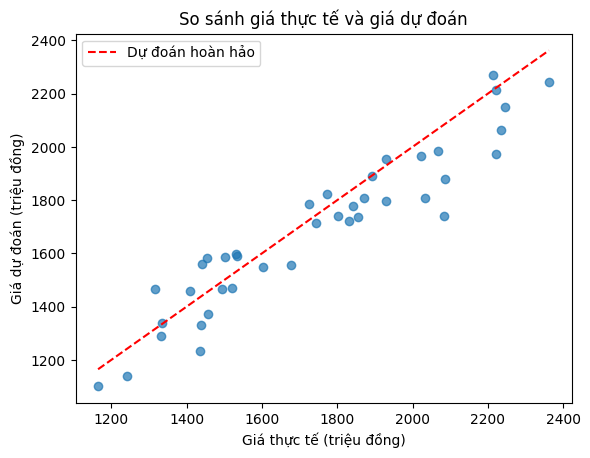

In [74]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
y_pred = knn_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MAE (sai số tuyệt đối trung bình): {mae:.1f} triệu đồng')
print(f'R2 (hệ số xác định): {r2:.3f}')

plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Dự đoán hoàn hảo')
plt.xlabel('Giá thực tế (triệu đồng)'); plt.ylabel('Giá dự đoán (triệu đồng)')
plt.title('So sánh giá thực tế và giá dự đoán')
plt.legend()
plt.show()

Bước 6: Thử nhiều giá trị k để chọn số láng giềng phù hợp

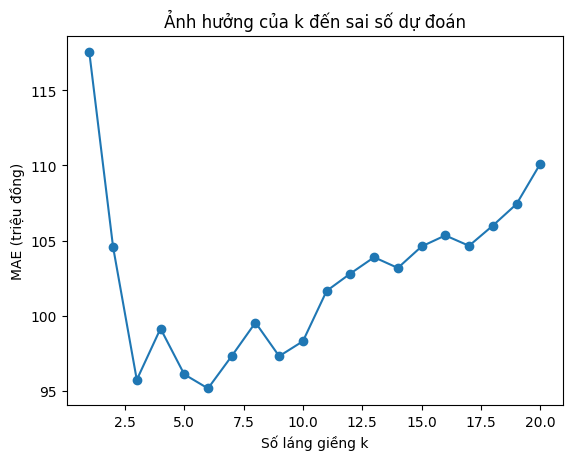

k cho sai số MAE thấp nhất: 6 - MAE: 95.2


In [75]:
mae_list = []
dai_k = range(1, 21)
for k in dai_k:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_train_scaled, y_train)
    mae_list.append(mean_absolute_error(y_test, m.predict(X_test_scaled)))

plt.plot(dai_k, mae_list, marker='o')
plt.xlabel('Số láng giềng k'); plt.ylabel('MAE (triệu đồng)')
plt.title('Ảnh hưởng của k đến sai số dự đoán')
plt.show()

k_tot_nhat = dai_k[np.argmin(mae_list)]
print('k cho sai số MAE thấp nhất:', k_tot_nhat, '- MAE:', round(min(mae_list), 1))

Bước 7 (MỚI): Ước tính giá cho một căn nhà mới do người dùng nhập vào

In [76]:
knn_final = KNeighborsRegressor(n_neighbors=k_tot_nhat)
knn_final.fit(X_train_scaled, y_train)

print('=== ƯỚC TÍNH GIÁ NHÀ MỚI ===')
print("(Nhập 'q' ở bước nhập diện tích để dừng)")

while True:
    nhap = input('\nNhập diện tích (m²) — hoặc q để dừng: ')
    if nhap.strip().lower() == 'q':
        break
    dien_tich_moi = float(nhap)
    so_phong_moi = float(input('Nhập số phòng ngủ: '))

    nha_moi = np.array([[dien_tich_moi, so_phong_moi]])
    nha_moi_scaled = scaler.transform(nha_moi)
    gia_du_doan = knn_final.predict(nha_moi_scaled)[0]

    print(f'=> Giá nhà ước tính: {gia_du_doan:,.0f} triệu đồng')

=== ƯỚC TÍNH GIÁ NHÀ MỚI ===
(Nhập 'q' ở bước nhập diện tích để dừng)

Nhập diện tích (m²) — hoặc q để dừng: 48
Nhập số phòng ngủ: 1
=> Giá nhà ước tính: 1,087 triệu đồng

Nhập diện tích (m²) — hoặc q để dừng: q


Bài tập mở rộng

So sánh MAE và R² khi có và không chuẩn hóa dữ liệu (bỏ qua Bước 4, dùng trực tiếp X_train/X_test chưa chuẩn hóa) — nhận xét sự khác biệt.

Không chuẩn hóa dữ liệu (bỏ qua StandardScaler)

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện KNN Regression với k=5
knn_raw = KNeighborsRegressor(n_neighbors=5)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)

mae_raw = mean_absolute_error(y_test, y_pred_raw)
r2_raw = r2_score(y_test, y_pred_raw)

print("MAE trước chuẩn hóa:", mae_raw)
print("R² trước chuẩn hóa:", r2_raw)


MAE trước chuẩn hóa: 99.48350472890604
R² trước chuẩn hóa: 0.8402232661159196


Có chuẩn hóa dữ liệu (dùng StandardScaler)

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn_scaled = KNeighborsRegressor(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
y_pred_scaled = knn_scaled.predict(X_test_s)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("MAE sau chuẩn hóa:", mae_scaled)
print("R² sau chuẩn hóa:", r2_scaled)


MAE sau chuẩn hóa: 96.11169707532024
R² sau chuẩn hóa: 0.8628474158351455


Thêm một đặc trưng mới (ví dụ: số tầng, khoảng cách đến trung tâm thành phố) vào dữ liệu mô phỏng và huấn luyện lại mô hình

Thêm đặc trưng mới vào dữ liệu mô phỏng  + Ví dụ, ta thêm đặc trưng số tầng hoặc khoảng cách đến trung tâm thành phố:

In [79]:
# Giả lập số tầng (1–5 tầng)
so_tang = np.random.randint(1, 6, n)

# Giả lập khoảng cách đến trung tâm (km, trung bình 8km, dao động 3km)
khoang_cach = np.random.normal(8, 3, n).clip(1, 20)

# Ghép thêm vào ma trận X
X_new = np.column_stack([dien_tich, so_phong, so_tang, khoang_cach])

# Cập nhật công thức giá nhà (ví dụ: thêm ảnh hưởng số tầng và khoảng cách)
gia_nha_new = 300 + dien_tich * 15 + so_phong * 80 + so_tang * 50 - khoang_cach * 20 + np.random.normal(0, 100, n)


Chuẩn hóa dữ liệu và huấn luyện lại mô hình K-NN Regression

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_new, gia_nha_new, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_s, y_train)
y_pred = knn_reg.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE với 4 đặc trưng:", mae)
print("R² với 4 đặc trưng:", r2)


MAE với 4 đặc trưng: 116.24628584375071
R² với 4 đặc trưng: 0.7990448026841568


So sánh kết quả K-NN Regression với mô hình LinearRegression (hồi quy tuyến tính, từ sklearn.linear_model) trên cùng bộ dữ liệu — mô hình nào cho MAE thấp hơn?

Huấn luyện K-NN Regression  
Bạn đã có code từ trước, chỉ cần giữ nguyên:

In [81]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_s, y_train)
y_pred_knn = knn_reg.predict(X_test_s)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("K-NN Regression → MAE:", mae_knn, " | R²:", r2_knn)


K-NN Regression → MAE: 116.24628584375071  | R²: 0.7990448026841568


Huấn luyện LinearRegression

In [82]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train)
y_pred_lin = lin_reg.predict(X_test_s)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression → MAE:", mae_lin, " | R²:", r2_lin)


Linear Regression → MAE: 65.24078707639072  | R²: 0.9364436852256885


Mới: Mở Google Drive trên trình duyệt, vào thư mục KNN_DuLieu, kiểm tra cả hai file ho_so_vay_von.csv (Bài 1) và gia_nha.csv (Bài 2) đã lưu cùng chỗ

Mới: Thử thêm một cột mới vào file CSV trong Drive (ví dụ: gán thêm 'so_tang' bằng công thức đơn giản), lưu lại bằng df.to_csv(...), rồi đọc lại và huấn luyện mô hình với 3 đặc trưng.

Thêm cột mới vào DataFrame và lưu lại CSV  + Ví dụ, ta thêm đặc trưng số tầng bằng công thức đơn giản:

In [83]:
import pandas as pd

# Đọc lại dữ liệu gốc
df = pd.read_csv(duong_dan_file)

# Thêm cột số tầng (giả lập từ 1–5 tầng)
df['so_tang'] = np.random.randint(1, 6, len(df))

# Lưu lại vào CSV
df.to_csv(duong_dan_file, index=False)

print(df.head())


    dien_tich  so_phong      gia_nha  so_tang
0   92.417854       3.0  1766.825041        1
1   76.543392       3.0  1628.213385        5
2   96.192213       4.0  2063.407572        5
3  118.075746       4.0  2395.834256        1
4   74.146166       1.0  1447.185937        3


Đọc lại dữ liệu và huấn luyện mô hình với 3 đặc trưng

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Đọc lại file CSV đã có thêm cột
df = pd.read_csv(duong_dan_file)

X = df[['dien_tich', 'so_phong', 'so_tang']].values
y = df['gia_nha'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_s, y_train)
y_pred = knn_reg.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE với 3 đặc trưng:", mae)
print("R² với 3 đặc trưng:", r2)


MAE với 3 đặc trưng: 100.57950649256216
R² với 3 đặc trưng: 0.8356391332105251


Mới: Thử nhập cùng một căn nhà (diện tích, số phòng) hai lần: một lần quên scaler.transform(), một lần làm đúng — so sánh 2 kết quả dự đoán để thấy rõ tầm quan trọng của bước chuẩn hóa dữ liệu mới

Huấn luyện mô hình và nhập cùng một căn nhà hai lần  
Ví dụ căn nhà có diện tích 100 m² và 3 phòng ngủ:

In [85]:
X = df[['dien_tich', 'so_phong']].values
y = df['gia_nha'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_final = KNeighborsRegressor(n_neighbors=5)
knn_final.fit(X_train_scaled, y_train)

# Nhập căn nhà mới với 2 đặc trưng
nha_moi = np.array([[100, 3]])
nha_moi_scaled = scaler.transform(nha_moi)
gia_du_doan_scaled = knn_final.predict(nha_moi_scaled)[0]
print("Dự đoán khi chuẩn hóa đúng:", gia_du_doan_scaled)


Dự đoán khi chuẩn hóa đúng: 1965.3797844487763
